# 📌AI Job Automation Risk Classification Using Machine Learning

# 1️⃣ Introduction
Artificial Intelligence is transforming industries and reshaping the job market. Many job roles are increasingly exposed to automation due to rapid AI adoption and evolving skill requirements.

This project aims to build a machine learning model that predicts the automation risk level (Low, Medium, High) of job roles based on workforce transformation indicators such as skill gaps, AI disruption intensity, and wage volatility.

# 2️⃣Problem Statement
To develop a multi-class classification model that predicts job automation risk categories using job-related economic and skill-based features.

Target Variable:

0 → Low Automation Risk

1 → Medium Automation Risk

2 → High Automation Risk

# 3️⃣Dataset Description
.Total Records: 15,000

.Multiple numerical and categorical features

.Key Features Include:

.skill_gap_index

.reskilling_urgency_score

.ai_disruption_intensity

.skill_transition_pressure

.ai_adoption_level

.wage_volatility_index

.salary_change_percent

.job_role

.remote_feasibility_score

.skill_demand_growth_percent

The dataset represents workforce dynamics and AI adoption impact across various job roles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4️⃣ Data Preprocessing

Removed unnecessary columns (if any)

Encoded categorical variables (job_role)

Checked for missing values

Split dataset into training and testing sets (80-20 split)

Train-Test Split ensures the model generalizes well on unseen data.

In [2]:
df=pd.read_csv("ai_job_replacement.csv")
df.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [3]:
print("shape of dataset:",df.shape)

print("\nColumns:\n",df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:\n",df.isnull().sum())

shape of dataset: (15000, 20)

Columns:
 Index(['job_id', 'job_role', 'industry', 'country', 'year',
       'automation_risk_percent', 'ai_replacement_score', 'skill_gap_index',
       'salary_before_usd', 'salary_after_usd', 'salary_change_percent',
       'skill_demand_growth_percent', 'remote_feasibility_score',
       'ai_adoption_level', 'education_requirement_level',
       'automation_risk_category', 'skill_transition_pressure',
       'wage_volatility_index', 'reskilling_urgency_score',
       'ai_disruption_intensity'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   job_id                       15000 non-null  int64  
 1   job_role                     15000 non-null  object 
 2   industry                     15000 non-null  object 
 3   country                 

In [4]:
df.describe()

,job_id,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,2022.997200,46.176347,46.155907,50.003708,89771.375196,89870.633937,0.114268,5.020461,54.898078,49.798269,3.01540,48.090028,7.986441,35.867584,23.006933
std,4330.271354,1.999365,21.663635,22.351347,28.811040,34522.125434,35897.592992,10.029197,9.956155,25.863593,28.860725,1.40512,18.107573,6.067153,12.416415,18.242259
min,0.000000,2020.000000,5.000000,4.010000,0.000000,30003.690000,19022.670000,-38.370000,-31.880000,10.010000,0.010000,1.00000,2.975000,0.000000,2.456000,0.003714
25%,3749.750000,2021.000000,28.790000,28.357500,25.170000,60127.225000,59223.457500,-6.640000,-1.662500,32.517500,24.707500,2.00000,34.900000,3.210000,26.982250,8.225829
50%,7499.500000,2023.000000,46.235000,45.675000,49.930000,89533.050000,88787.330000,0.150000,4.960000,54.775000,49.435000,3.00000,48.155000,6.665000,35.871000,18.642515
75%,11249.250000,2025.000000,63.602500,62.712500,75.025000,119823.840000,118432.967500,6.690000,11.730000,77.405000,74.795000,4.00000,61.296250,11.550000,44.698500,34.090823
max,14999.000000,2026.000000,94.980000,113.070000,99.980000,149984.060000,191961.210000,36.920000,49.790000,99.990000,99.980000,5.00000,96.340000,38.370000,71.579000,93.351726


In [5]:
#dropping unnecessary columns
df=df.drop(["job_id","automation_risk_percent","ai_replacement_score"],axis=1,errors="ignore")

In [6]:
from sklearn.preprocessing import LabelEncoder

categorical_cols=["job_role","industry","country"]
for col in categorical_cols:
    df[col]=LabelEncoder().fit_transform(df[col])
    target_encoder=LabelEncoder()
    df["automation_risk_category"]=target_encoder.fit_transform(df["automation_risk_category"])

In [7]:
#Define Features & Target
X=df.drop("automation_risk_category",axis=1)
y=df["automation_risk_category"]

In [8]:
#Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

# 5️⃣ Baseline Model – Random Forest

Random Forest was used as the baseline ensemble model.

Why Random Forest?

Handles non-linear relationships

Reduces overfitting using bagging

Works well with structured tabular data

Results:

Test Accuracy: ~96.5%

Cross-Validation Accuracy: ~96.39%

The small difference between test accuracy and CV accuracy indicates strong generalization and minimal overfitting.

In [9]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)

In [10]:
#Evaluate Model
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
print("\nConfusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.9613333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97       902
           1       0.97      0.95      0.96       803
           2       0.95      0.96      0.96      1295

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000


Confusion Matrix:
 [[ 876    0   26]
 [   0  765   38]
 [  27   25 1243]]


# Feature Importance Analysis

Feature importance revealed the most influential predictors:

-skill_gap_index

-reskilling_urgency_score

-ai_disruption_intensity

-skill_transition_pressure

-ai_adoption_level

Interpretation:
Automation risk is primarily driven by skill mismatch, AI disruption intensity, and workforce transition pressure.

#Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns
importances=rf.feature_importances_
feature_names=X.columns
feat_imp=pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances}).sort_values(by="Importance",ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(10),x="Importance",y="Feature")
plt.title("Top 10 Important Features")
plt.show()

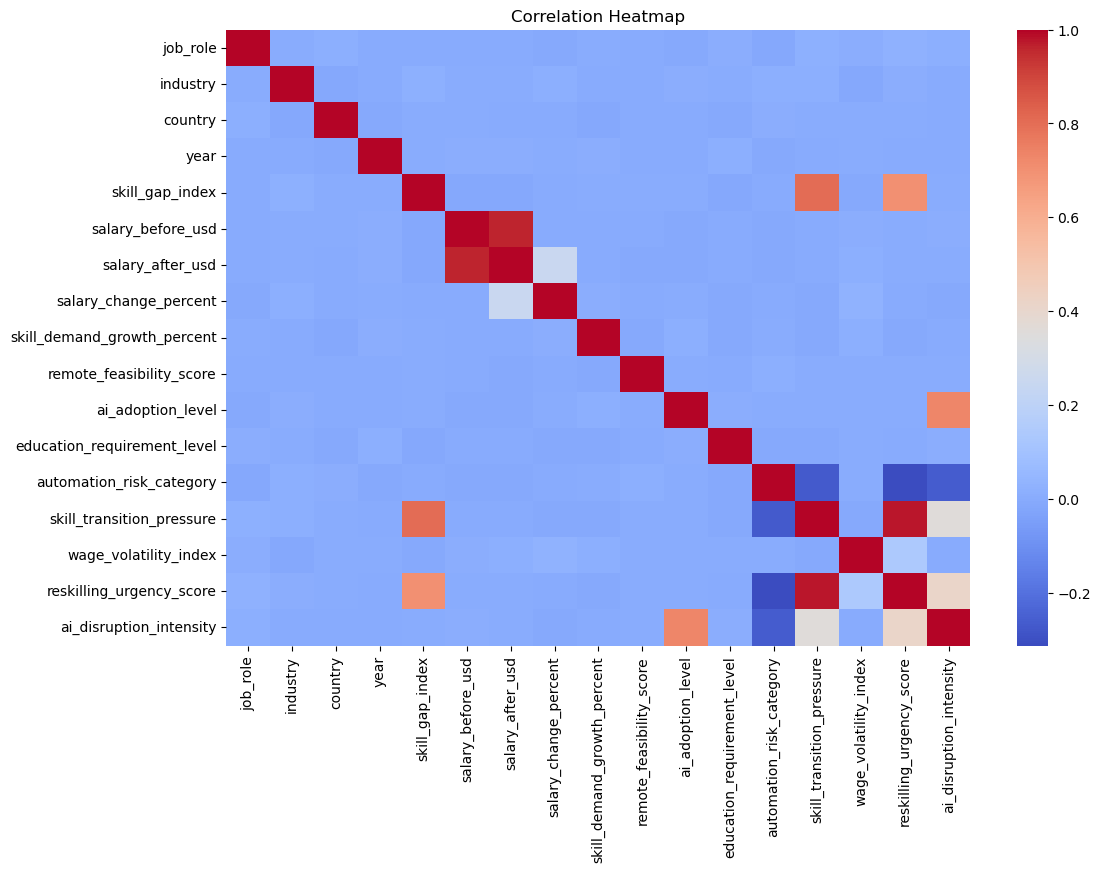

In [12]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [13]:
#cross validation
from sklearn.model_selection import cross_val_score
cv_scores=cross_val_score(rf,X,y,cv=5)
print("Cross Validation Scores:",cv_scores)
print("Average CV Score:",cv_scores.mean())

Cross Validation Scores: [0.965      0.965      0.96333333 0.96633333 0.95766667]
Average CV Score: 0.9634666666666668


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

print("Starting Cross Validation...")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

scores = cross_val_score(rf, X, y, cv=5)

print("Done!")
print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Starting Cross Validation...
Done!
Scores: [0.96566667 0.96266667 0.96133333 0.972      0.962     ]
Mean Accuracy: 0.9647333333333334


# 6️⃣ Hyperparameter Tuning

--GridSearchCV was applied to optimize:

n_estimators

max_depth

min_samples_split

min_samples_leaf

--Best Parameters:

max_depth = 20

min_samples_split = 5

n_estimators = 150

--Best CV Score: ~96.28%

The performance remained similar to default Random Forest, indicating the baseline model was already near optimal.

In [15]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
#Define parameter grid
param_grid={
    'n_estimators':[100,150],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}
rf=RandomForestClassifier(random_state=42,n_jobs=-1)
grid_search=GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X,y)
print("Best Parameters:",grid_search.best_params_)
print("Best CV Score:",grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
Best CV Score: 0.9628666666666668


In [19]:
!pip install xgboost --upgrade --no-cache-dir

# 7️⃣ Model Comparison – XGBoost

To further improve performance, XGBoost (a boosting algorithm) was implemented.

Why XGBoost?

-Sequential learning

-Corrects errors of previous trees

-Captures complex feature interactions

Results:

-XGBoost Cross-Validation Accuracy: ~97.81%

XGBoost outperformed Random Forest, demonstrating superior ability to model complex workforce transformation patterns.

In [21]:
#XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
xgb=XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss'
)
scores=cross_val_score(xgb,X,y,cv=5)
print("XGBoost CV Scores:",scores)
print("Mean XGBoost Accuracy:",scores.mean())

XGBoost CV Scores: [0.977      0.97833333 0.98       0.97966667 0.97566667]
Mean XGBoost Accuracy: 0.9781333333333333


# 9️⃣ ROC Curve Analysis

A multi-class ROC curve was generated using One-vs-Rest strategy.

Results:

-AUC ≈ 1.00 for all classes

This indicates excellent class separability and strong probability ranking capability of the model.

Although accuracy is ~97.8%, the ROC curve shows near-perfect discrimination between automation risk categories.

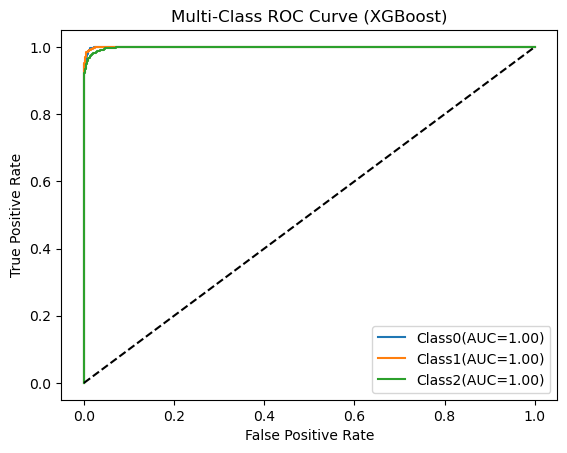

In [24]:
#ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#Split data
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
#Train XGBoost
xgb.fit(X_train,y_train)

#predict probabilities
y_score=xgb.predict_proba(X_test)

#Binarize labels
y_test_bin=label_binarize(y_test,classes=[0,1,2])
n_classes=y_test_bin.shape[1]

#Plot ROC for each class
for i in range(n_classes):
    fpr,tpr,_=roc_curve(y_test_bin[:,i],y_score[:,i])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"Class{i}(AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (XGBoost)")
plt.legend()
plt.show()

# Key Insights

1.Higher skill gaps significantly increase automation risk.

2.Industries with high AI adoption levels show higher disruption intensity.

3.Wage volatility and skill demand growth contribute to classification.

4.Boosting models (XGBoost) perform better than bagging models for this dataset.

# Conclusion

This project successfully developed a high-performance multi-class classification model for predicting job automation risk.

Key Achievements:

-Achieved 97.8% cross-validation accuracy using XGBoost

-Demonstrated strong generalization ability

-Achieved near-perfect ROC-AUC

-Identified major workforce risk indicators

The model effectively captures patterns related to AI-driven workforce transformation.

# Future Improvements

-Implement SHAP for explainability

-Deploy model using Streamlit

-Validate using real-world labor datasets

-Perform feature interaction analysis